In [11]:
from cirq_sic import *

d = 2
base_dir = "data/sky_ground"
wh_implementation = "simple"

N = 20
thetas = np.linspace(0, np.pi, N)
phis = np.linspace(0, 2*np.pi, N)

n_shots = 50000
tasks = {(theta, phi): CharacterizeWHReferenceDeviceTask(\
             **{"dataset_id": "bloch",
               "processor_id": "willow_pink",
               "run_type": "clean",
               "qubits": get_wh_qubits(d, wh_implementation),
               "n_shots": n_shots,
               "optimizer": "cirq",
               "d": d,
               "fiducial": np.array([np.cos(theta/2), np.exp(1j*phi)*np.sin(theta/2)]),
               "fiducial_description": f"bloch_{np.round(theta, 4)}_{np.round(phi, 4)}",
               "wh_implementation": wh_implementation}) for phi in phis for theta in thetas}

for (theta, phi), task in tasks.items():
    run_sky_ground_task(task, base_dir=base_dir)

2026-04-01 00:39:07 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.0_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Starting task...
2026-04-01 00:39:07 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.0_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Creating circuits...
2026-04-01 00:39:07 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.0_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Optimizing circuits...


2026-04-01 00:39:07 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.0_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Sampling...
2026-04-01 00:39:08 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.0_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Processing results...
2026-04-01 00:39:08 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.0_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Saving...
2026-04-01 00:39:08 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.1653_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Starting task...
2026-04-01 00:39:08 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.1653_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Creating circuits...
2026-04-01 00:39:08 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.1653_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Optimizing circuits...
2026-04-01 00:39:08 [INFO] bloch/d2/CharacterizeWHReferenceDeviceTask/simple/bloch_0.1653_0.0/cirq_clean_n50k_wi

In [61]:
def calculate_magic(P, alpha):
    return (1/(1-alpha))*np.log(np.sum(P[:,0]**alpha)) - np.log(d)

def caculate_LTP_deformation(P):
    return np.linalg.norm(np.linalg.pinv(P) - np.eye(d**2))

alpha = 2
magic = np.zeros((N, N))
exact_magic = np.zeros((N, N))
deform = np.zeros((N, N))
exact_deform = np.zeros((N, N))

Theta, Phi = np.meshgrid(thetas, phis)
theta_ind = {theta: i for i, theta in enumerate(thetas)}
phi_ind = {phi: i for i, phi in enumerate(phis)}

for (theta, phi), task in tasks.items():
    results = load_results(task)
    P = np.array(results["processed_data"]["P"])
    exact_P = exactify(task)["P"]

    magic[theta_ind[theta], phi_ind[phi]] = calculate_magic(P, alpha)
    exact_magic[theta_ind[theta], phi_ind[phi]] = calculate_magic(exact_P, alpha)
    deform[theta_ind[theta], phi_ind[phi]] = caculate_LTP_deformation(P)
    exact_deform[theta_ind[theta], phi_ind[phi]] = caculate_LTP_deformation(exact_P)

max_magic = (1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d)
sic_quantumness = np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d)))

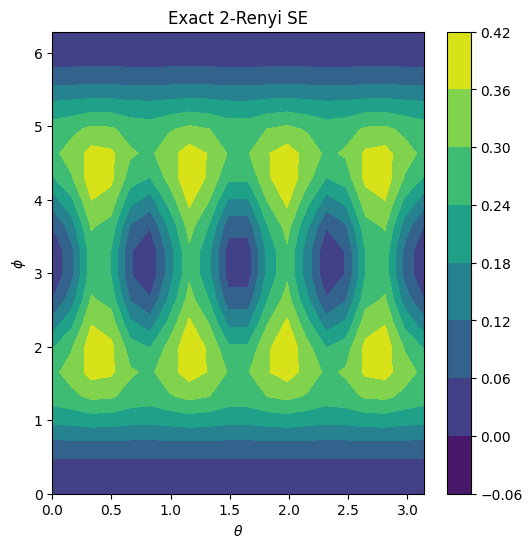

In [42]:
fig, ax = plt.subplots(1, figsize=(6,6))
cs = ax.contourf(Theta, Phi, exact_magic)
fig.colorbar(cs)
ax.set_title("Exact %d-Renyi SE" % alpha)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
fig.savefig("bloch_exact_magic.pdf")

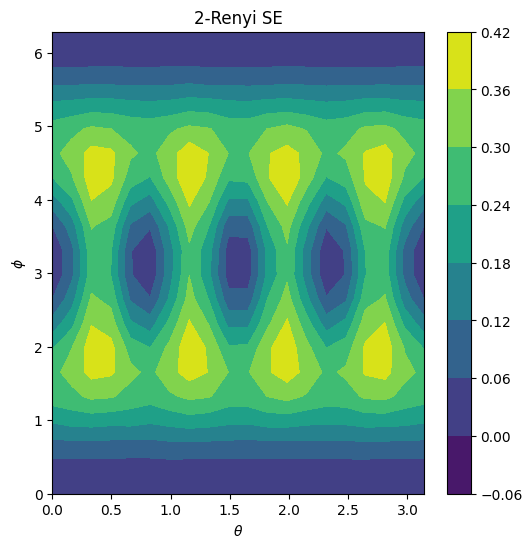

In [43]:
fig, ax = plt.subplots(1, figsize=(6,6))
cs = ax.contourf(Theta, Phi, magic)
fig.colorbar(cs)
ax.set_title("%d-Renyi SE" % alpha)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
fig.savefig("bloch_magic.pdf")

In [62]:
cutoff = 50

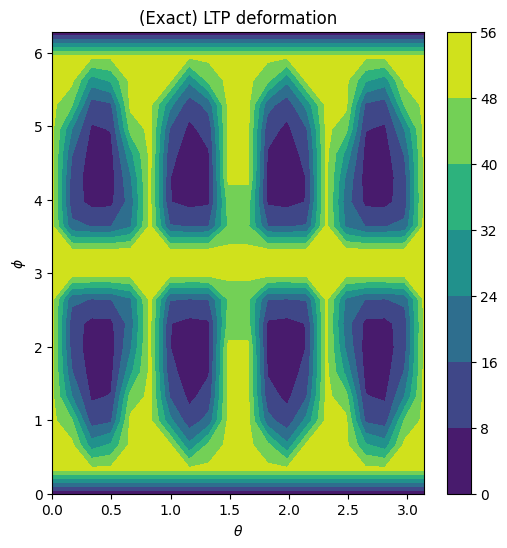

In [64]:
fig, ax = plt.subplots(1, figsize=(6,6))
exact_deform_mat = exact_deform.copy()
exact_deform_mat[exact_deform_mat > cutoff] = cutoff
cs = ax.contourf(Theta, Phi, exact_deform_mat)
fig.colorbar(cs)
ax.set_title("(Exact) LTP deformation")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
fig.savefig("bloch_exact_deform.pdf")

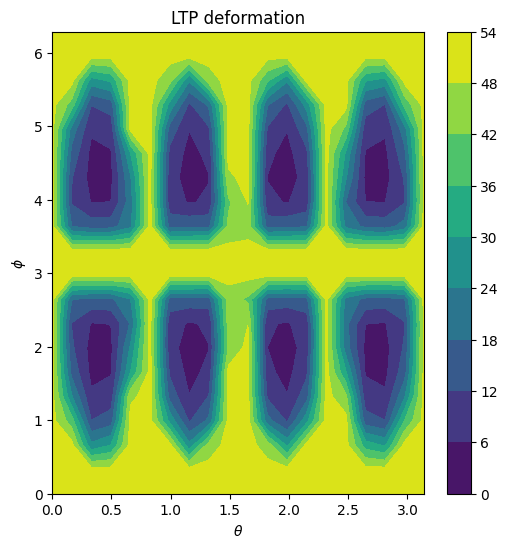

In [66]:
fig, ax = plt.subplots(1, figsize=(6,6))
deform_mat = deform.copy()
deform_mat[deform_mat > cutoff] = cutoff
cs = ax.contourf(Theta, Phi, deform_mat)
fig.colorbar(cs)
ax.set_title("LTP deformation")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
fig.savefig("bloch_deform.pdf")